# 01 - EDA: Animals-10

Dataset: https://www.kaggle.com/datasets/alessiocorrado99/animal10

## Download (run once)
1. Get a Kaggle API token (kaggle.com -> Account -> Create New API Token), save `kaggle.json` to `~/.kaggle/kaggle.json`.
2. Run the cell below to download and unzip into `data/raw/`.

In [ ]:
# !kaggle datasets download -d alessiocorrado99/animal10 -p ../data/raw --unzip

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.utils import LABEL_TRANSLATE

DATA_DIR = Path("../data/raw/animals10/raw-img")

## Class balance

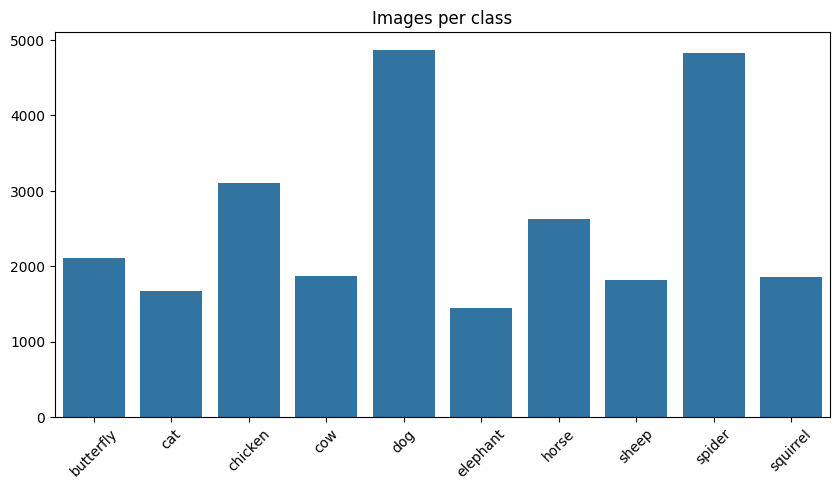

{'butterfly': 2112,
 'cat': 1668,
 'chicken': 3098,
 'cow': 1866,
 'dog': 4863,
 'elephant': 1446,
 'horse': 2623,
 'sheep': 1820,
 'spider': 4821,
 'squirrel': 1862}

In [2]:
counts = {}
for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        label = LABEL_TRANSLATE.get(class_dir.name, class_dir.name)
        counts[label] = len(list(class_dir.glob("*")))

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(rotation=45)
plt.title("Images per class")
plt.show()
counts

## Sample images

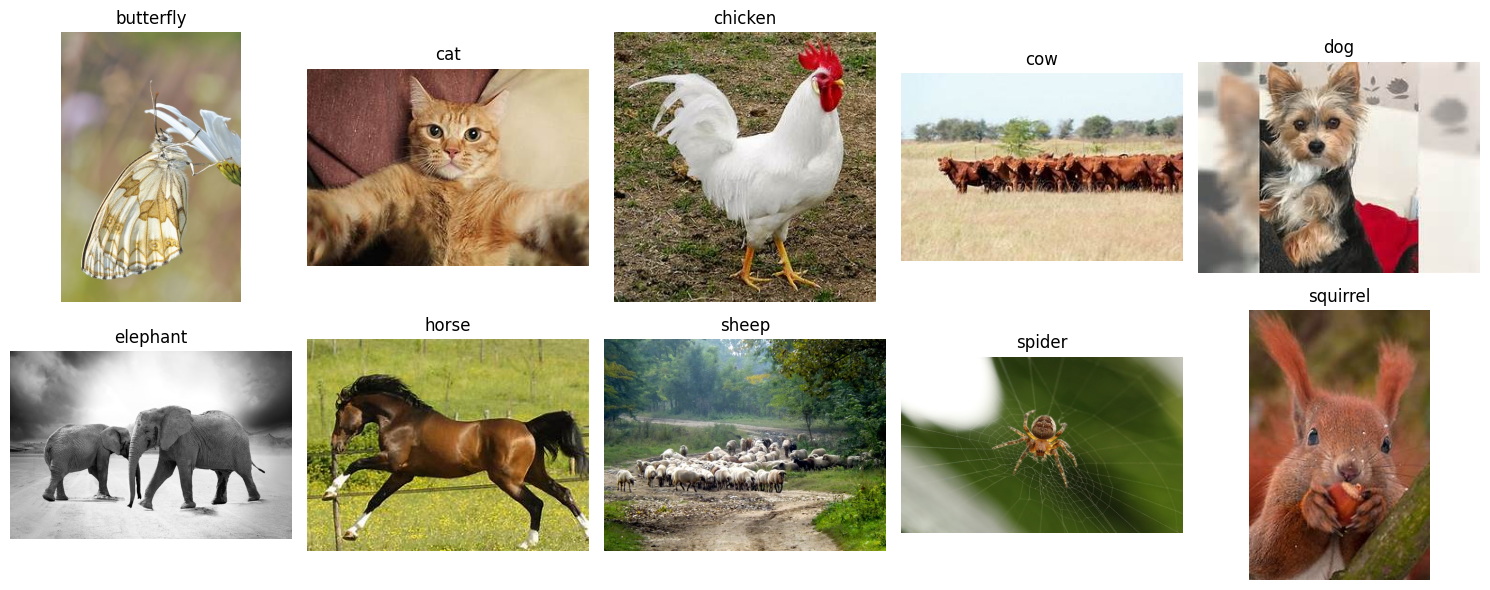

In [3]:
class_dirs = [d for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, class_dir in zip(axes.flat, class_dirs):
    sample_path = next(class_dir.glob("*"))
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(LABEL_TRANSLATE.get(class_dir.name, class_dir.name))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Image size distribution
Check if image dimensions vary a lot (informs resize strategy in `src/utils.py` -> `IMG_SIZE`).

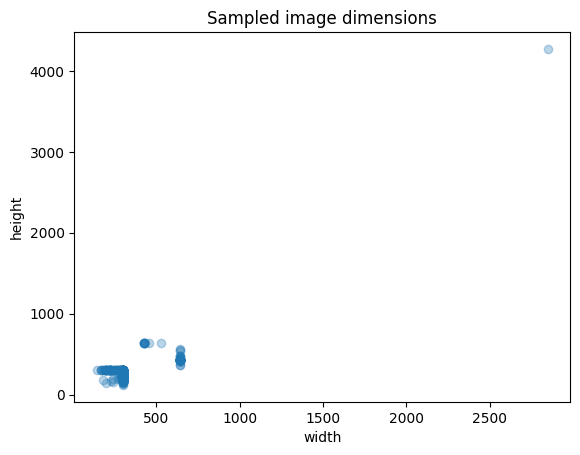

In [4]:
import random

sizes = []
for class_dir in class_dirs:
    files = list(class_dir.glob("*"))
    for f in random.sample(files, min(50, len(files))):
        with Image.open(f) as img:
            sizes.append(img.size)

widths, heights = zip(*sizes)
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("width")
plt.ylabel("height")
plt.title("Sampled image dimensions")
plt.show()